## Let's gooo

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pickle


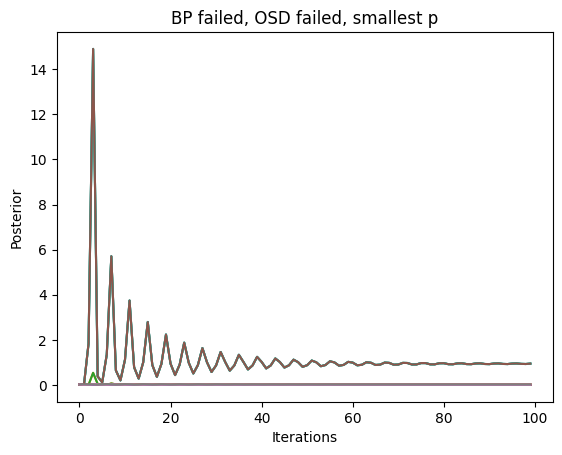

In [ ]:
d=100

y = np.array(posteriors[9][3])[:, :, 1]
x = np.arange(0, len(y))

for qubit in range(y.shape[1]):
    plt.plot(x[0:d], y[:, qubit][0:d])

plt.xlabel('Iterations')
plt.ylabel('Posterior')
plt.title('BP failed, OSD failed, smallest p');


In [ ]:
save_data = json.load(open('../scripts/metric_3x3_qubit_bpm.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/metric_3x3_qubit_bpm_post', 'rb') as handle:
    posteriors = pickle.load(handle)


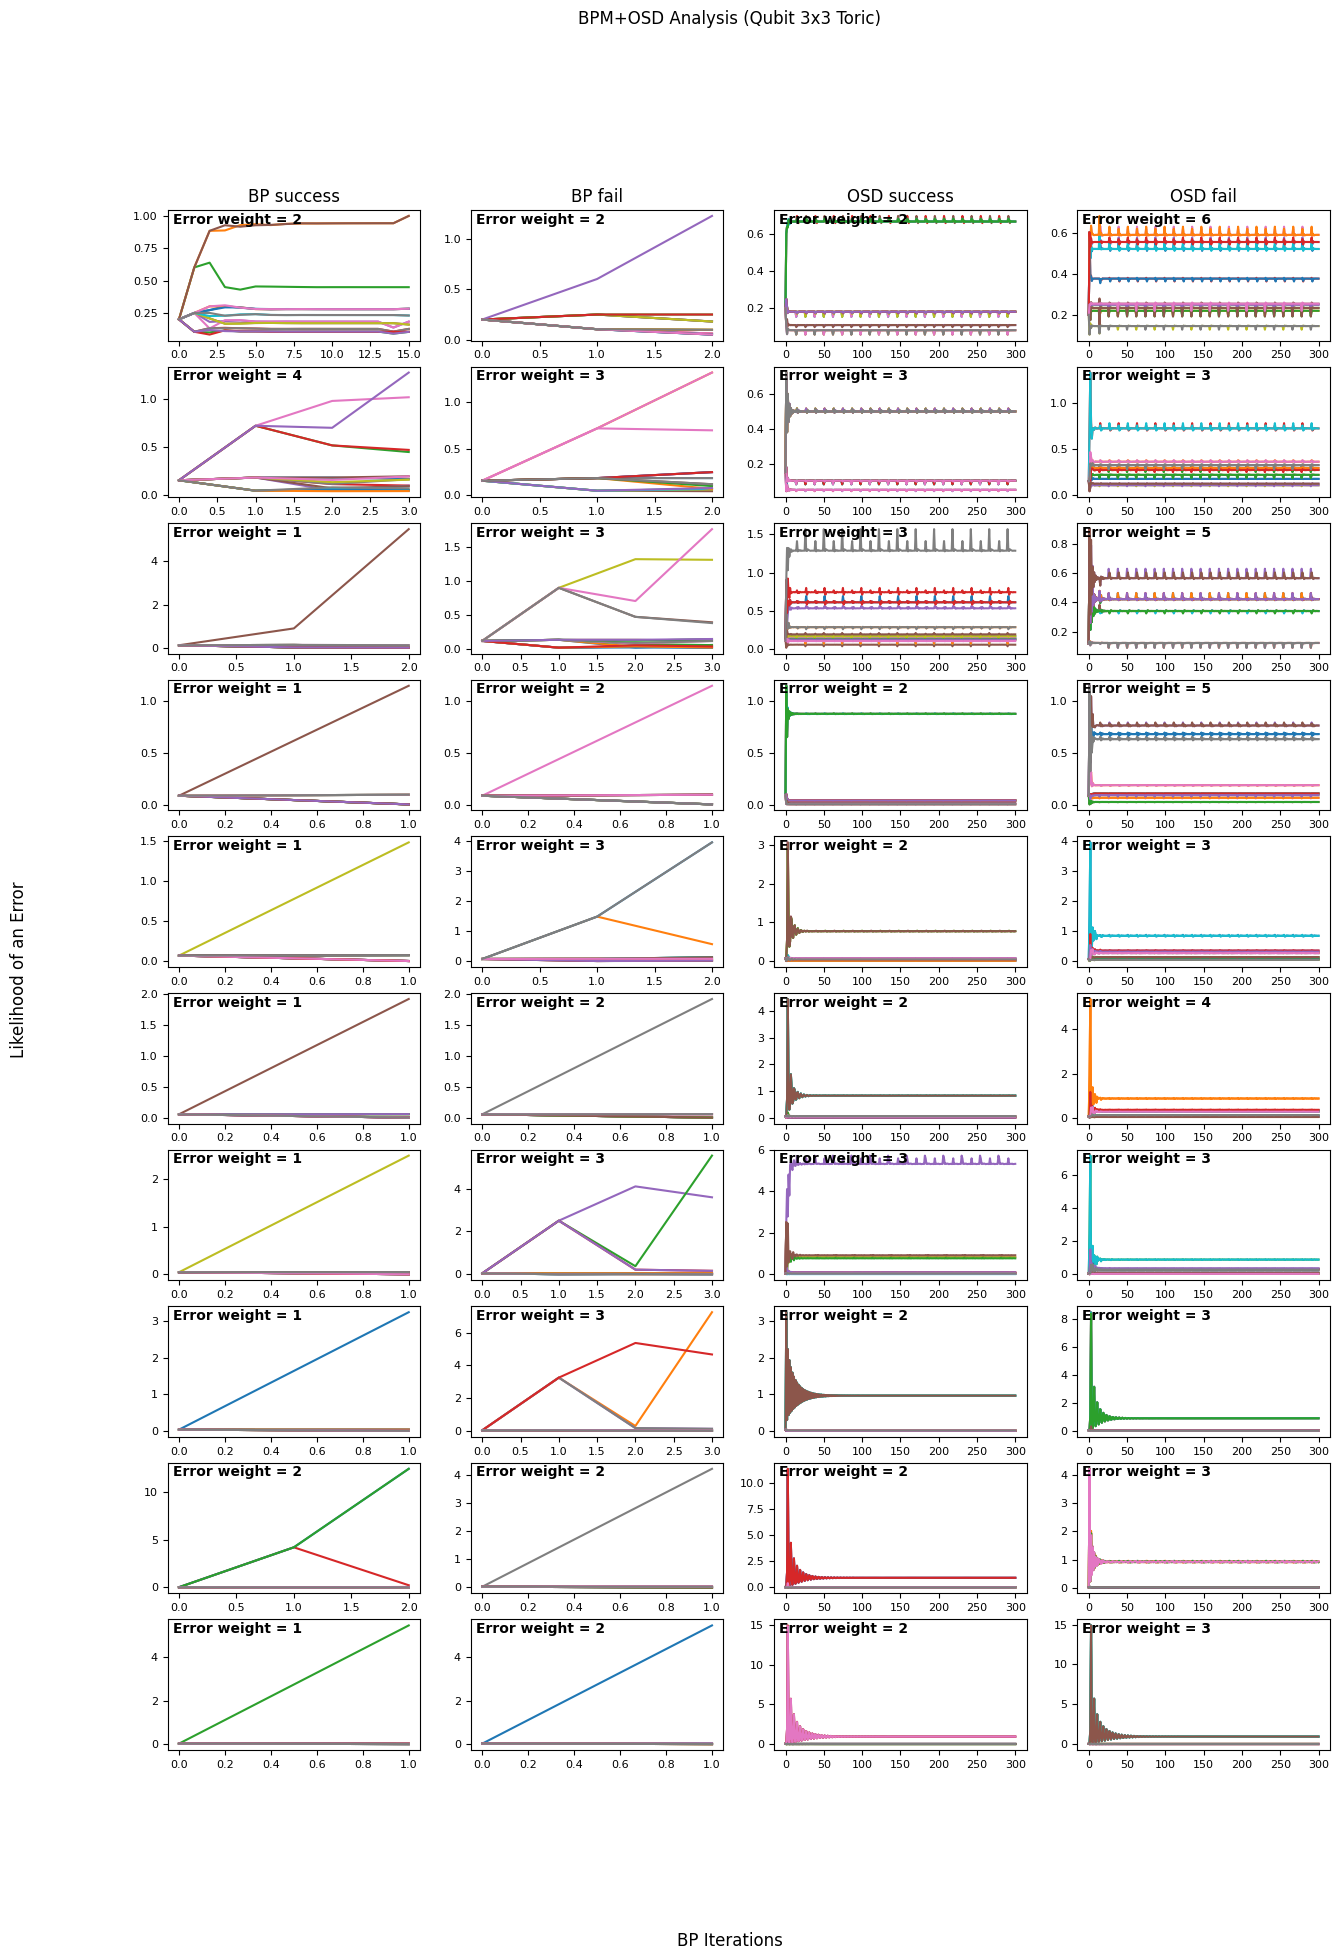

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(15, 20))

for row in range(10):
    for col in range(4):
        ax = axes[row, col]
        if (row==0) and (col==0):
            ax.set_title('BP success')
        if (row==0) and (col==1):
            ax.set_title('BP fail')
        if (row==0) and (col==2):
            ax.set_title('OSD success')
        if (row==0) and (col==3):
            ax.set_title('OSD fail')

        if not posteriors[row][col]:
            continue

        y = np.array(posteriors[row][col])[:, :, 1]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Likelihood of an Error')
fig.suptitle('BPM+OSD Analysis (Qubit 3x3 Toric)')

plt.show();


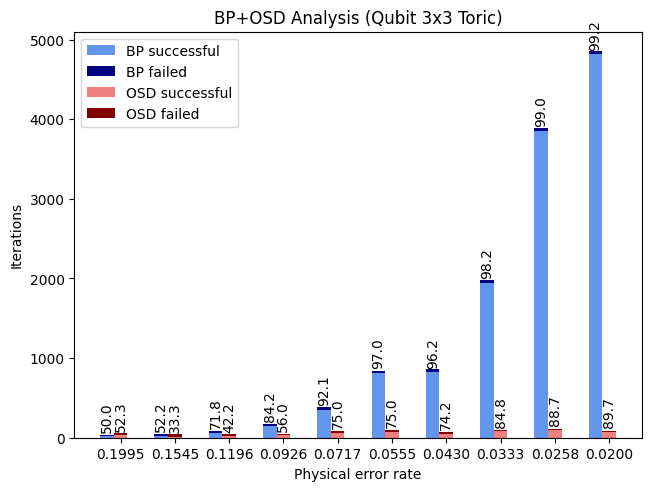

In [ ]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

multiplier += 1
offset = width * multiplier
rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('BPM+OSD Analysis (Qubit 3x3 Toric)')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()


In [ ]:
save_data = json.load(open('../scripts/metric_3x3_qutrit.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/metric_3x3_qutrit_post', 'rb') as handle:
    posteriors = pickle.load(handle)


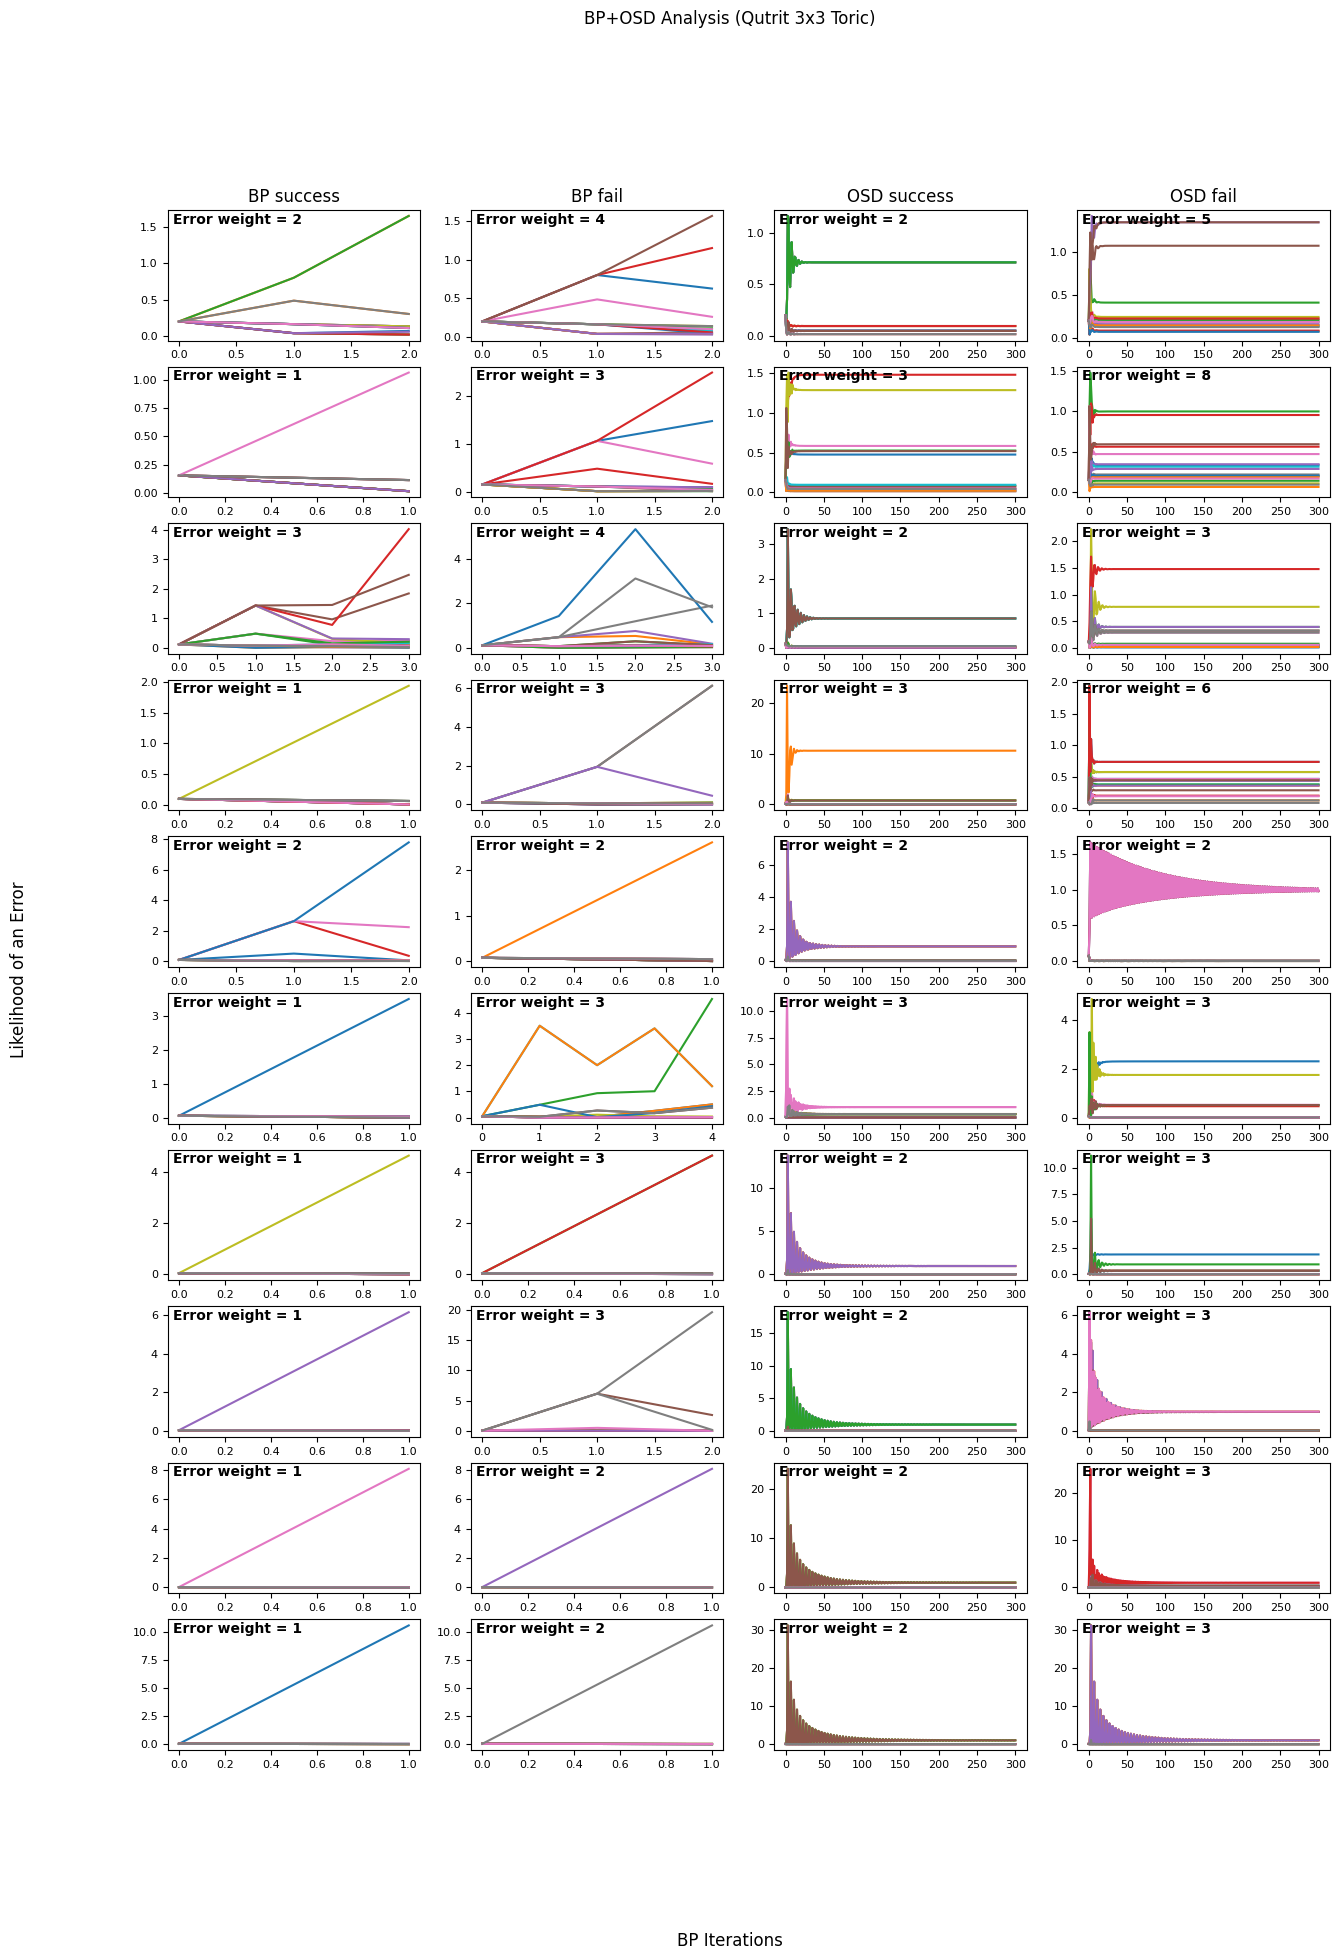

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(15, 20))

for row in range(10):
    for col in range(4):
        ax = axes[row, col]
        y = np.array(posteriors[row][col])[:, :, 1] + np.array(posteriors[row][col])[:, :, 2]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        if (row==0) and (col==0):
            ax.set_title('BP success')
        if (row==0) and (col==1):
            ax.set_title('BP fail')
        if (row==0) and (col==2):
            ax.set_title('OSD success')
        if (row==0) and (col==3):
            ax.set_title('OSD fail')

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Likelihood of an Error')
fig.suptitle('BP+OSD Analysis (Qutrit 3x3 Toric)')

plt.show();


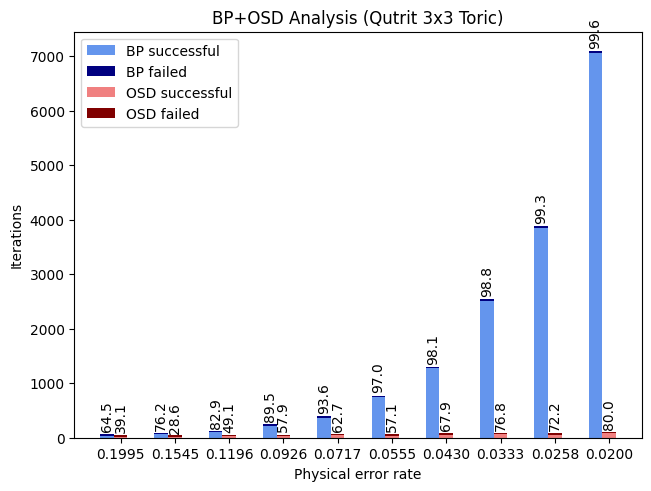

In [ ]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

multiplier += 1
offset = width * multiplier
rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('BP+OSD Analysis (Qutrit 3x3 Toric)')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()


In [ ]:
save_data = json.load(open('../scripts/metric_3x3_ququint.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/metric_3x3_ququint_post', 'rb') as handle:
    posteriors = pickle.load(handle)


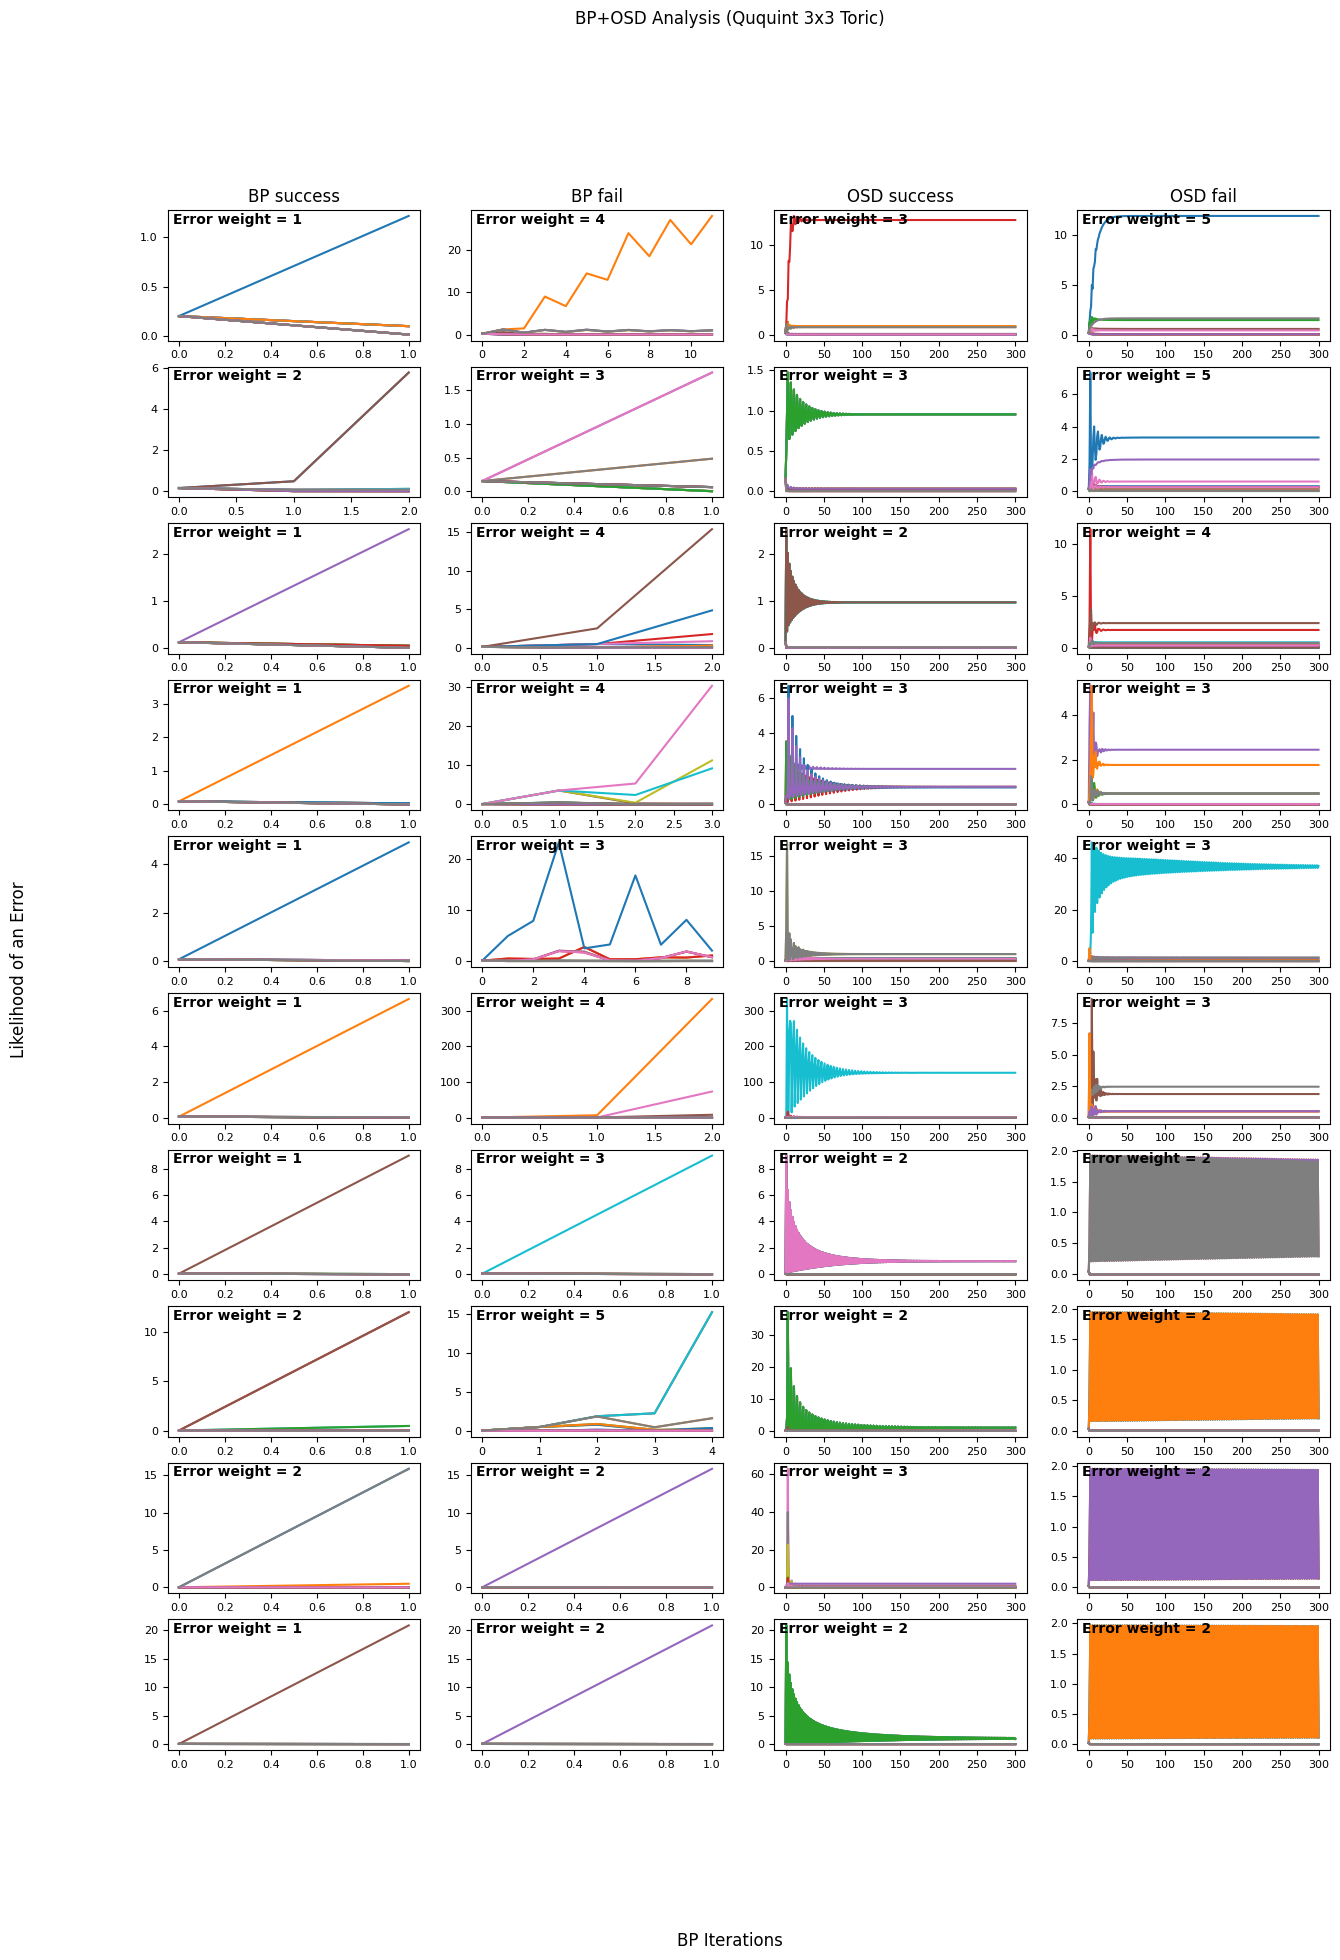

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(15, 20))

for row in range(10):
    for col in range(4):
        ax = axes[row, col]
        y = np.array(posteriors[row][col])[:, :, 1] + np.array(posteriors[row][col])[:, :, 2] + np.array(posteriors[row][col])[:, :, 3] + np.array(posteriors[row][col])[:, :, 4]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        if (row==0) and (col==0):
            ax.set_title('BP success')
        if (row==0) and (col==1):
            ax.set_title('BP fail')
        if (row==0) and (col==2):
            ax.set_title('OSD success')
        if (row==0) and (col==3):
            ax.set_title('OSD fail')

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Likelihood of an Error')
fig.suptitle('BP+OSD Analysis (Ququint 3x3 Toric)')

plt.show();


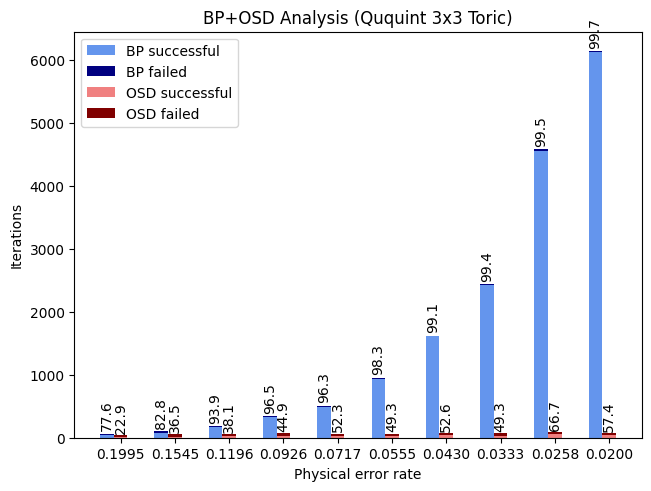

In [ ]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

multiplier += 1
offset = width * multiplier
rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('BP+OSD Analysis (Ququint 3x3 Toric)')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()
